# Finding and marking bad channels in the data



In [ ]:
#load in packagaes

import mne
import matplotlib_inline
import matplotlib.pyplot as plt
import os
import numpy as np
import os.path as op
import warnings
import inspect
from mne_bids import (
    BIDSPath,
    make_dataset_description,
    print_dir_tree,
    read_raw_bids,
)


import sys
import numpy as np

import mne
from mne_bids import BIDSPath, read_raw_bids
import matplotlib.pyplot as plt
import scipy
from mne.preprocessing import find_bad_channels_maxwell

warnings.filterwarnings('ignore')

----


In [ ]:
subject = '01'
session = '01'
task = 'face'
run = '01'


bids_root = '/Users/rekaforgo/Documents/Bachelor2025'  # path to BIDS root folder

bids_path = BIDSPath(subject=subject, session=session,
            task=task, run=run, suffix='meg', extension='.fif', root=bids_root)

deriv_root = op.join(bids_root, 'derivatives/preprocessing')  # output path

deriv_path = BIDSPath(subject=subject, session=session, datatype='meg',
            task=task, run=run, suffix='meg', root=deriv_root).mkdir()

deriv_fname = bids_path.basename.replace('meg', 'raw_sss') # output filename
deriv_file_1 = op.join(deriv_path.directory, deriv_fname)
deriv_file_2 = deriv_file_1.replace('run-01', 'run-02')



In [23]:
raw1 = read_raw_bids(bids_path=bids_path, 
                     extra_params={'preload':True},
                     verbose=True)
raw1.info['line_freq'] = 50  # specify line noise frequency

print(raw1.info)

Resolving symbolic link: /Users/rekaforgo/Documents/Bachelor2025/sub-01/ses-01/meg/sub-01_ses-01_task-face_run-01_meg.fif -> /Users/rekaforgo/Documents/Bachelor2025/.git/annex/objects/1J/0p/SHA256E-s84601620--67d9042189a96cc5e0ec779398e79d35abe3a8c35bf36bbeace49bcf6158afda.fif/SHA256E-s84601620--67d9042189a96cc5e0ec779398e79d35abe3a8c35bf36bbeace49bcf6158afda.fif
Opening raw data file /Users/rekaforgo/Documents/Bachelor2025/.git/annex/objects/1J/0p/SHA256E-s84601620--67d9042189a96cc5e0ec779398e79d35abe3a8c35bf36bbeace49bcf6158afda.fif/SHA256E-s84601620--67d9042189a96cc5e0ec779398e79d35abe3a8c35bf36bbeace49bcf6158afda.fif...
Isotrak not found
    Range : 0 ... 325339 =      0.000 ...   325.339 secs
Ready.
Reading 0 ... 325339  =      0.000 ...   325.339 secs...


/var/folders/0y/tt7d7wj97hbf8tnc9hnp1_f00000gn/T/ipykernel_47065/4268136483.py:1: RuntimeWarning: This filename (/Users/rekaforgo/Documents/Bachelor2025/.git/annex/objects/1J/0p/SHA256E-s84601620--67d9042189a96cc5e0ec779398e79d35abe3a8c35bf36bbeace49bcf6158afda.fif/SHA256E-s84601620--67d9042189a96cc5e0ec779398e79d35abe3a8c35bf36bbeace49bcf6158afda.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw1 = read_raw_bids(bids_path=bids_path,


Reading events from /Users/rekaforgo/Documents/Bachelor2025/sub-01/ses-01/meg/sub-01_ses-01_task-face_run-01_events.tsv.
Reading channel info from /Users/rekaforgo/Documents/Bachelor2025/sub-01/ses-01/meg/sub-01_ses-01_task-face_run-01_channels.tsv.
<Info | 12 non-empty values
 bads: []
 ch_names: MEG01, MEG02, MEG03, MEG04, MEG05, MEG06, MEG07, MEG08, MEG09, ...
 chs: 64 Magnetometers, 1 Stimulus
 custom_ref_applied: False
 experimenter: PKU XU WEI
 file_id: 4 items (dict)
 highpass: 0.0 Hz
 line_freq: 50.0
 lowpass: 500.0 Hz
 meas_date: unspecified
 meas_id: 4 items (dict)
 nchan: 65
 projs: []
 sfreq: 1000.0 Hz
 subject_info: <subject_info | his_id: sub-01, sex: 1, hand: 1>
>


In [31]:
#do we have ref meg channels?

ValueError: meg value must be one of ['grad', 'mag', 'planar1', 'planar2'] or bool, not ref_meg

In [24]:

raw1_copy = raw1.copy()

psds, freqs = raw1_copy.compute_psd(fmin=1, fmax=150, method='welch').get_data(return_freqs=True)

# Compute median PSD per frequency, then relative power per channel
median_psd = np.median(psds, axis=0)
relative_power = psds / median_psd

# Flag channels whose total power is abnormally high
total_power = psds.sum(axis=1)
threshold = np.median(total_power) * 10  # 10× above median is suspicious
bad_chs = [ch for ch, p in zip(raw1_copy.ch_names, total_power) if p > threshold]

print("Detected noisy channels:", bad_chs)
raw1.info["bads"] = bad_chs

Effective window size : 2.048 (s)
Detected noisy channels: ['MEG08', 'MEG16', 'MEG18', 'MEG46', 'MEG47', 'MEG61', 'MEG64']


In [25]:
flat_chs = [
    ch for ch, data in zip(raw1_copy.ch_names, raw1_copy.get_data())
    if np.std(data) < 1e-12  # depends on your units; adjust threshold
]
print("Flat channels:", flat_chs)
raw1.info["bads"].extend(flat_chs)

Flat channels: []


In [26]:
raw1.info["bads"]

['MEG08', 'MEG16', 'MEG18', 'MEG46', 'MEG47', 'MEG61', 'MEG64']

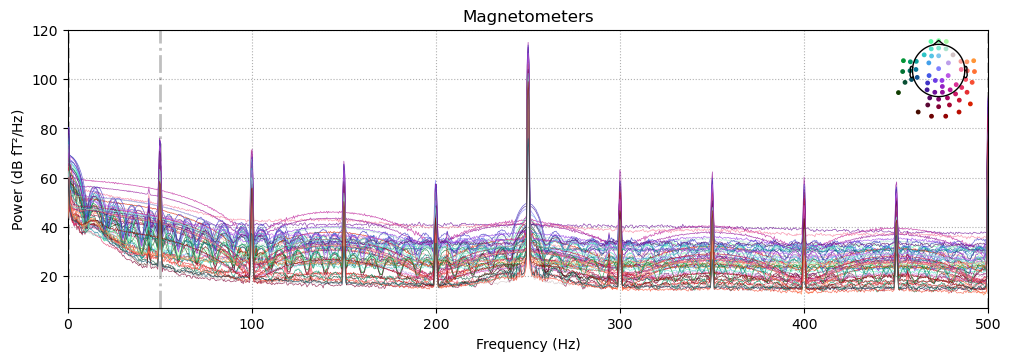

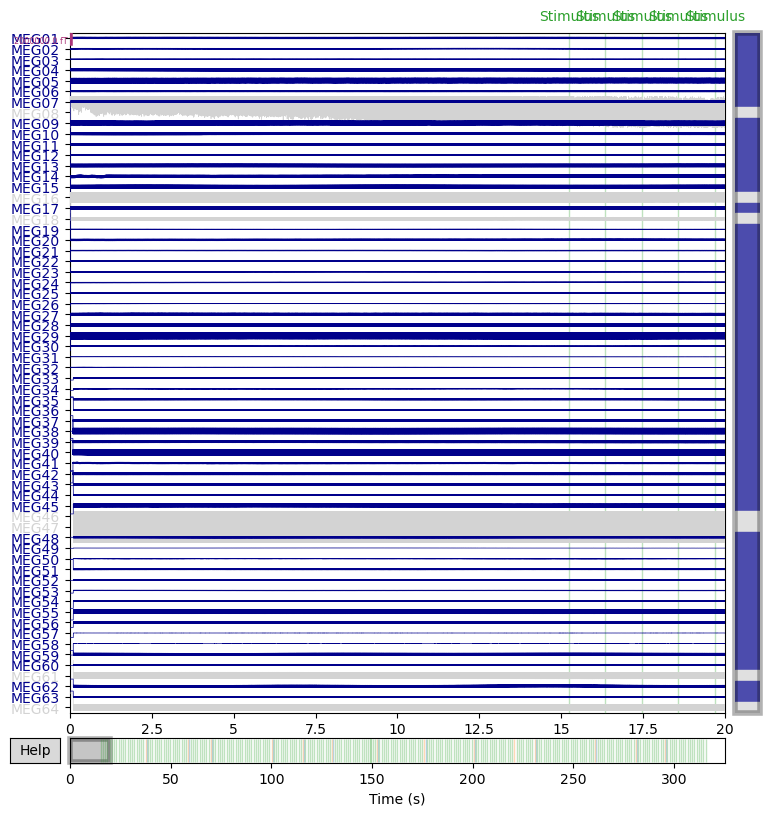

In [27]:
#plotting to see if bad channels are marked
raw1.plot(
    picks='mag',
    duration=20,
    scalings=1e-9, 
    n_channels=64
);

In [28]:
n_fft = 2000 # achieving a 0.5 Hz frequency resolution
raw1_psd = raw1.compute_psd('welch', fmin=0.0, fmax=120, picks="mag", n_fft=n_fft, n_overlap=int(n_fft // 2))

Effective window size : 2.000 (s)


Plotting power spectral density (dB=True).


/opt/anaconda3/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


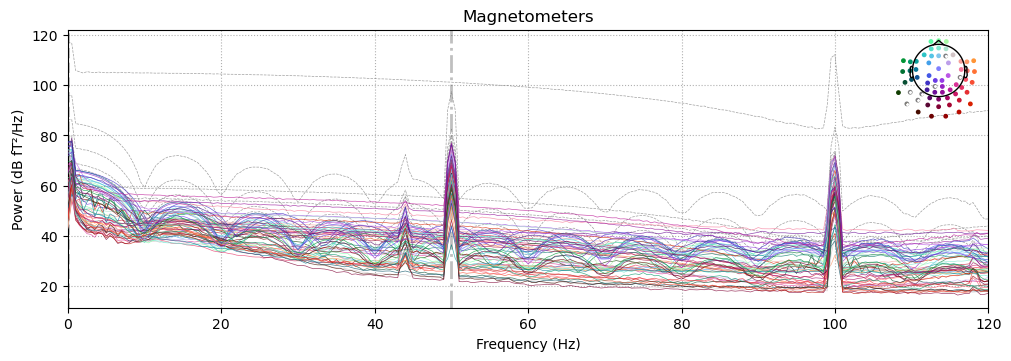

In [29]:
#print psd
raw1_psd.plot()

In [ ]:
#filter out line noise and also just regular setup
